In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame = pd.read_csv("diamonds.csv")

In [3]:
data_frame.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
data_frame = data_frame.drop("Unnamed: 0", axis=1) #diyerek bu gereksiz column'u kaldirabiliriz

In [5]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [6]:
data_frame.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### goruldugu uzere x, y ve z icin 0 degerinin oldugunu goruyoruz. ama boyle bir sey mumkun degil. 0 demek yoktur oyle bir sey demektir. o yuzden bunu ele alacagiz. <br><br> Eger az sayida varsa silecegiz yok coksa median veya mean ile dolduracagiz

In [7]:
print(data_frame[data_frame["x"] == 0] , "\n")
print(data_frame[data_frame["y"] == 0] , "\n")
print(data_frame[data_frame["z"] == 0] , "\n")

       carat        cut color clarity  depth  table  price    x     y    z
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.0  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.0  0.00  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.0  0.00  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.0  0.00  0.0
26243   1.20    Premium     D    VVS1   62.1   59.0  15686  0.0  0.00  0.0
27429   2.25    Premium     H     SI2   62.8   59.0  18034  0.0  0.00  0.0
49556   0.71       Good     F     SI2   64.1   60.0   2130  0.0  0.00  0.0
49557   0.71       Good     F     SI2   64.1   60.0   2130  0.0  0.00  0.0 

       carat        cut color clarity  depth  table  price    x    y    z
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.0  0.0  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.0  0.0  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.0  0.0  0.0
26243   1.20    Premium    

#### gordugmuz gibi az sayida var bunlari silebiliriz

In [8]:
print(data_frame[data_frame["z"] == 0].index) #diyerek indexleri cekebiliriz. drop() fonksiyonuna index vermeliyiz 0 'lı row'lari silmek icin


data_frame = data_frame.drop(data_frame[data_frame["z"] == 0].index)
data_frame = data_frame.drop(data_frame[data_frame["x"] == 0].index)
data_frame = data_frame.drop(data_frame[data_frame["y"] == 0].index)

Index([ 2207,  2314,  4791,  5471, 10167, 11182, 11963, 13601, 15951, 24394,
       24520, 26123, 26243, 27112, 27429, 27503, 27739, 49556, 49557, 51506],
      dtype='int64')


In [9]:
data_frame.describe() # 0 larin gittigini gormus olacagiz

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


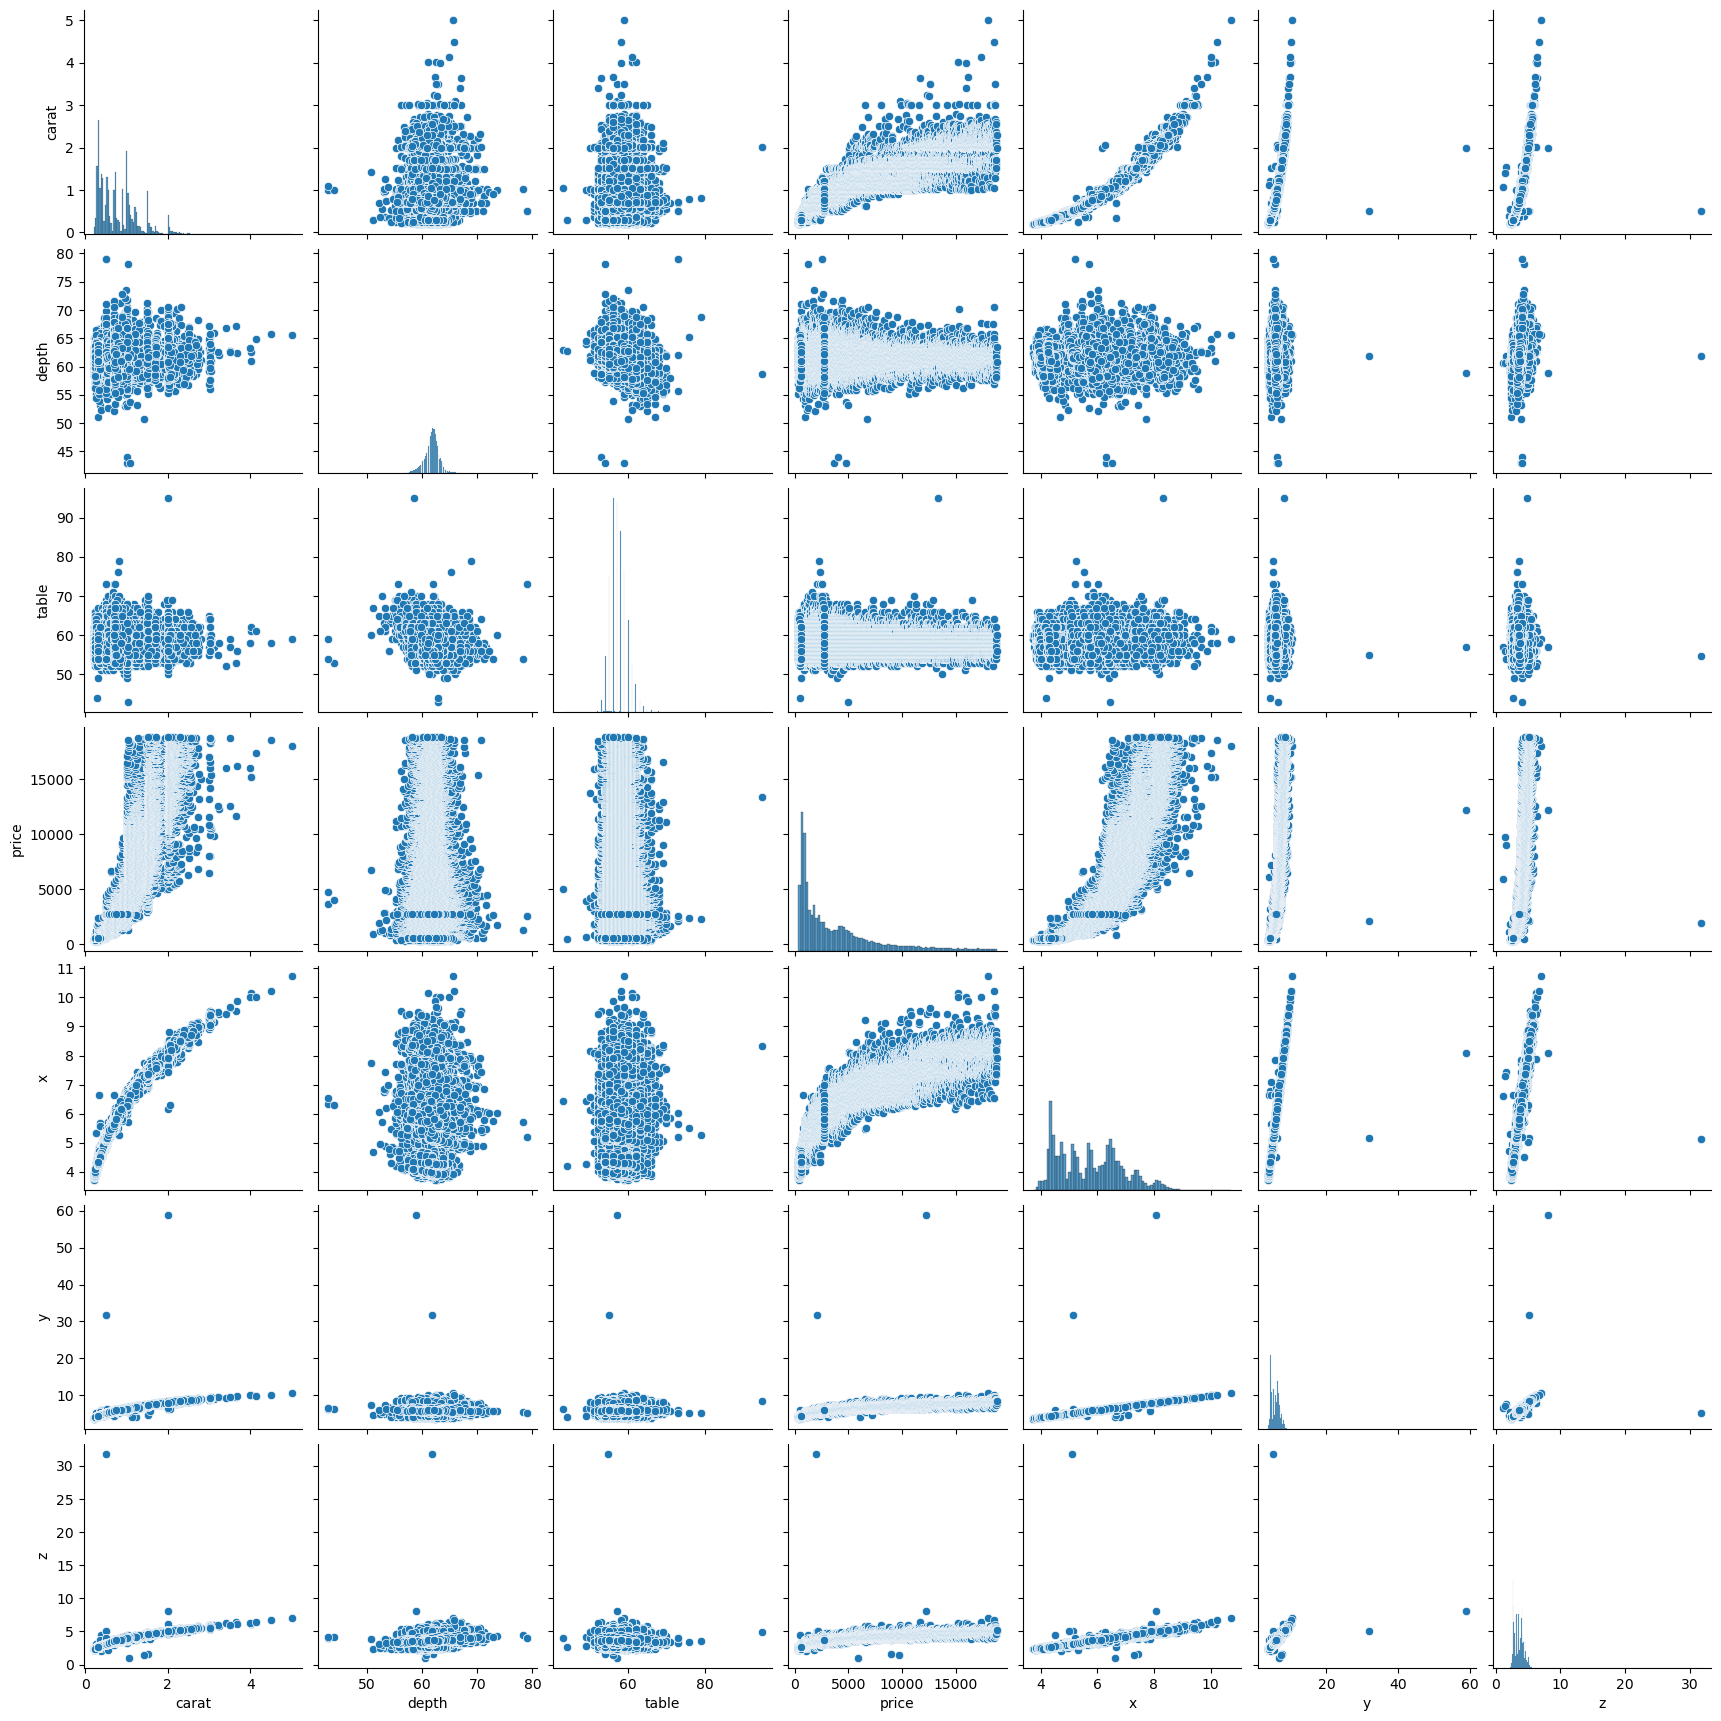

In [10]:
sns.pairplot(data_frame)
plt.show()

### burdan iste "price" ile iliskilere bakacak olursak outlier'lar oldugunu gorebiliriz

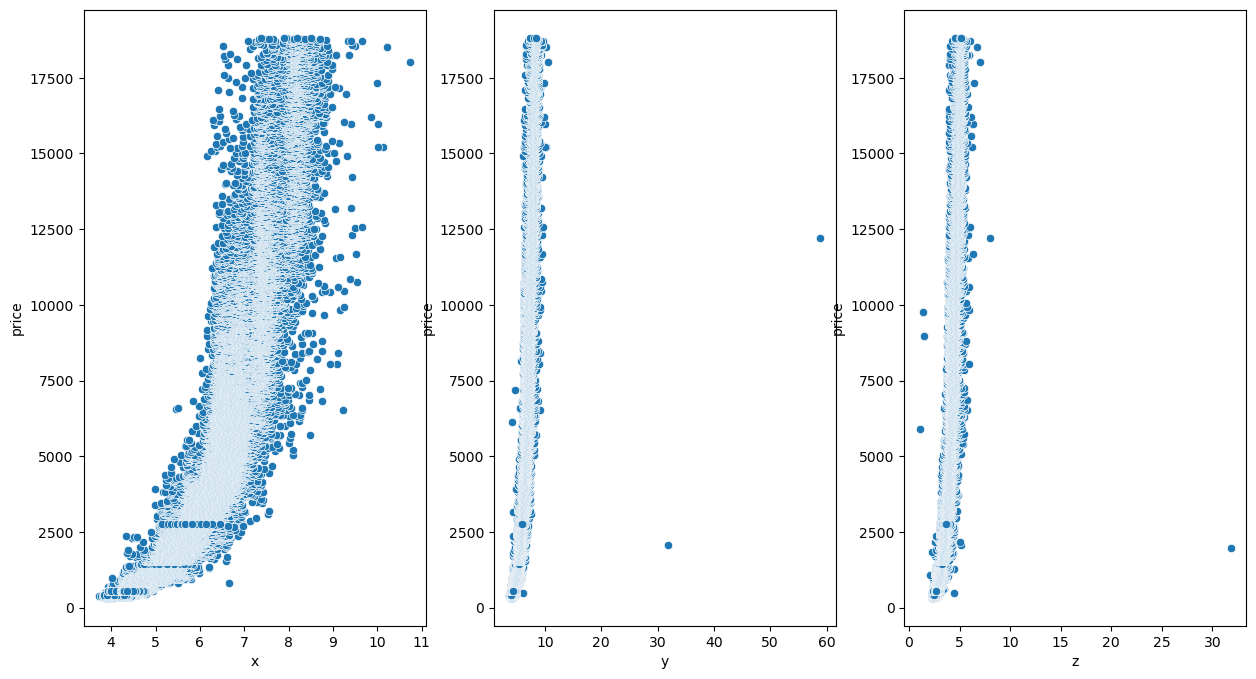

In [11]:
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
sns.scatterplot(x=data_frame["x"], y=data_frame["price"])
plt.subplot(1,3,2)
sns.scatterplot(x=data_frame["y"], y=data_frame["price"])
plt.subplot(1,3,3)
sns.scatterplot(x=data_frame["z"], y=data_frame["price"])
plt.show()

### birkac tane outlier'ler var ,zaten goruluyor ve az yani. bunlari cikaralim

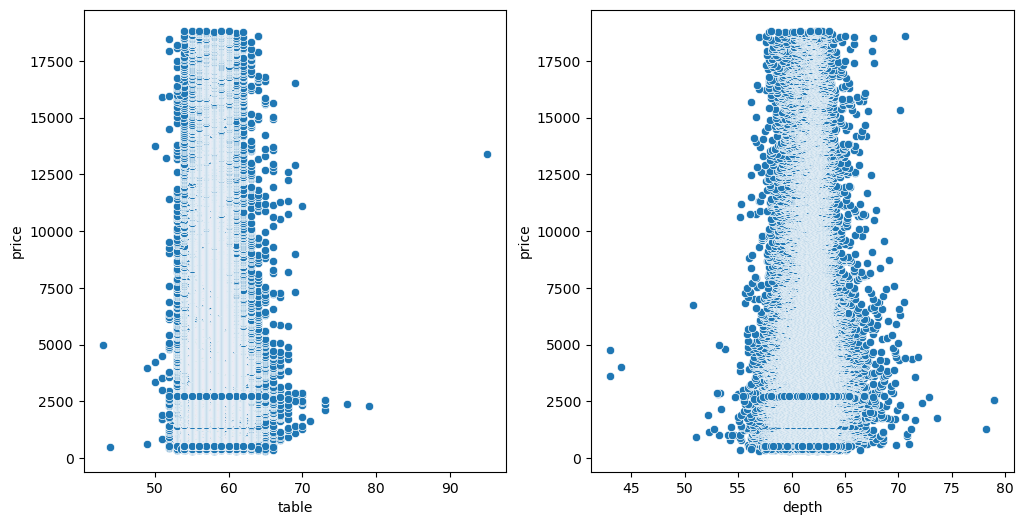

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(x=data_frame["table"], y=data_frame["price"])
plt.subplot(1,2,2)
sns.scatterplot(x=data_frame["depth"], y=data_frame["price"])
plt.show()

In [13]:
data_frame = data_frame[(data_frame["y"]<20)]
data_frame = data_frame[(data_frame["z"]<10) & (data_frame["z"]>2 )]
data_frame = data_frame[(data_frame["table"]<75) & (data_frame["table"]>45)]
data_frame = data_frame[(data_frame["depth"]<75) & (data_frame["depth"]>50 )]

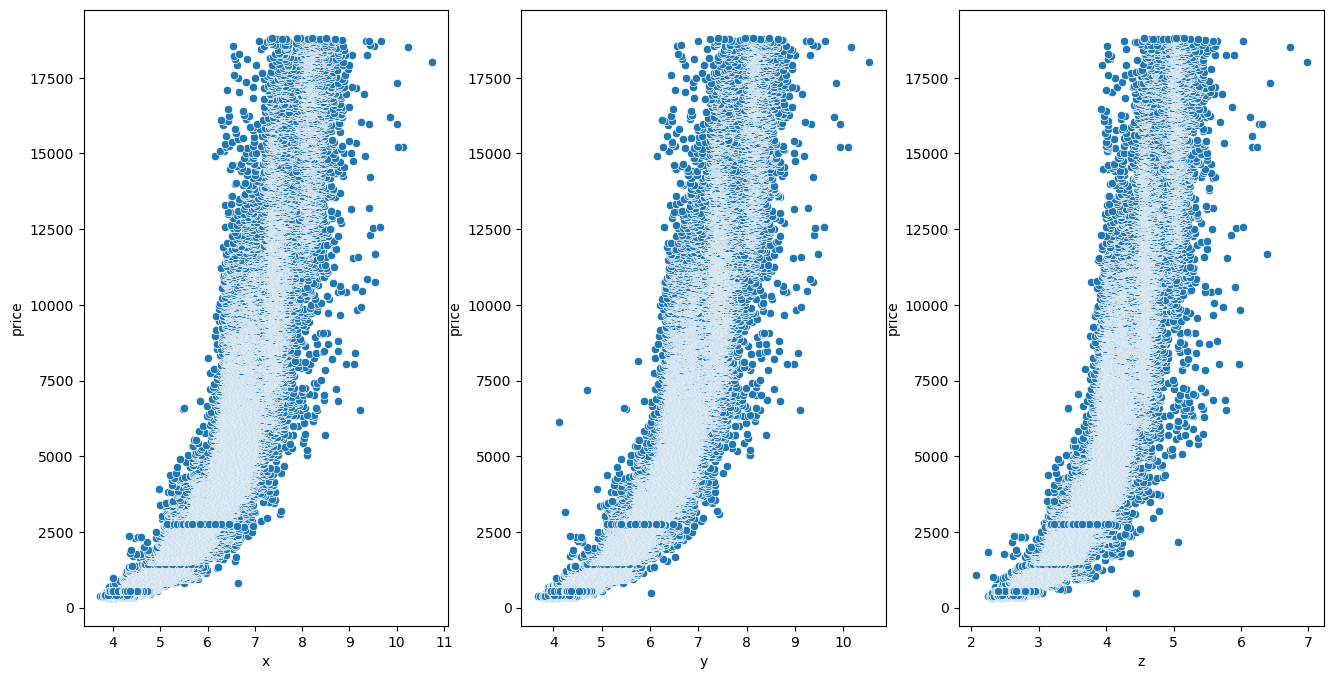

In [14]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
sns.scatterplot(x=data_frame["x"], y=data_frame["price"])
plt.subplot(1,3,2)
sns.scatterplot(x=data_frame["y"], y=data_frame["price"])
plt.subplot(1,3,3)
sns.scatterplot(x=data_frame["z"], y=data_frame["price"])
plt.show()

### onceki grafiklerden farki var goruldugu uzere

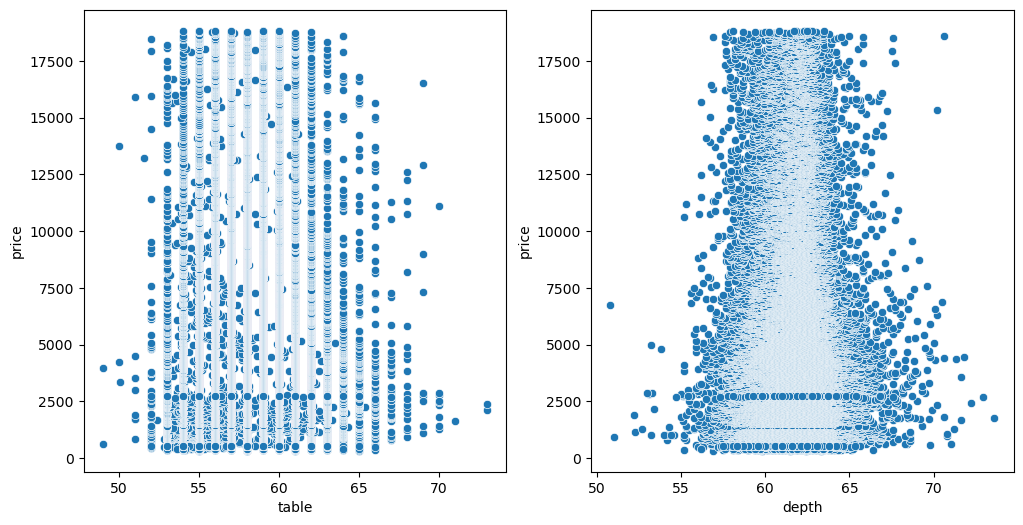

In [15]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(x=data_frame["table"], y=data_frame["price"])
plt.subplot(1,2,2)
sns.scatterplot(x=data_frame["depth"], y=data_frame["price"])
plt.show()

In [16]:
data_frame.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


#### kategorik degerleri ele alabiliriz

## Encoding & Scaling

In [17]:
print(data_frame["cut"].value_counts() ,"\n")
print(data_frame["color"].value_counts(),"\n")
print(data_frame["clarity"].value_counts())

#buyuk ihtimalle "label encoding" yapcaz her bir degere bir sayi vercez ki daha basit oluyor

cut
Ideal        21542
Premium      13779
Very Good    12079
Good          4902
Fair          1601
Name: count, dtype: int64 

color
G    11281
E     9791
F     9535
H     8296
D     6774
I     5419
J     2807
Name: count, dtype: int64 

clarity
SI1     13058
VS2     12250
SI2      9183
VS1      8165
VVS2     5066
VVS1     3654
IF       1790
I1        737
Name: count, dtype: int64


### Encoding işlemini train-test split'ten önce yapmak yerine, sonrasında yapmak çok daha mantıklıdır. Bunun temel nedeni veri sızıntısıdır (data leakage).<br><br>Veri sızıntısı, modelin eğitim aşamasında, normalde görmemesi gereken test verisinden bilgi almasıdır. Bu durum, modelin performansını yanlış değerlendirmene yol açar. Modelin test verisindeki başarısı yanıltıcı bir şekilde yüksek görünür, ancak gerçek hayattan gelen yeni verilerle karşılaştığında performansı düşer.<br><br>*__Önce train-test split yap:__ Veriyi ikiye ayırarak modelin test setinden haberdar olmamasını sağlarsın.<br>__*Sonra encoding yap:__ Dönüştürücüyü sadece eğitim verisinde eğitir ve test verisine uygularsın.

In [18]:
X=data_frame.drop("price", axis=1)
y=data_frame["price"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=15)

In [21]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

In [22]:
for column in ["cut", "color", "clarity"]:
    X_train[column] = label_encoder.fit_transform(X_train[column])
    X_test[column] = label_encoder.transform(X_test[column])

In [23]:
print(X_train["cut"].value_counts() ,"\n")
print(X_train["color"].value_counts(),"\n")
print(X_train["clarity"].value_counts())

#label_encoder edildigini gormus olacagiz. Tabi train seti oldugu icin data_frame'nin %75 tane verisinin geldigini gorecegiz

cut
2    16280
3    10251
4     9060
1     3658
0     1178
Name: count, dtype: int64 

color
3    8428
1    7363
2    7211
4    6152
0    5095
5    4090
6    2088
Name: count, dtype: int64 

clarity
2    9755
5    9210
3    6921
4    6080
7    3801
6    2787
1    1332
0     541
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import StandardScaler, RobustScaler

#Robust Scaler secenegi de vardir. Bu secenek outlier datalar icin daha iyi bir scale islemi yapar. bilgin olsun

In [25]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Ilk Yapilan Model Sonuclari

### ilk olarak bi lineer regresyon ile deneyelim ama hiperparametre yapmicaz

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mean abs error:  875.6032136997477 

mean sqr error:  1856711.3920588985 

r2 score:  0.8858160822630052 



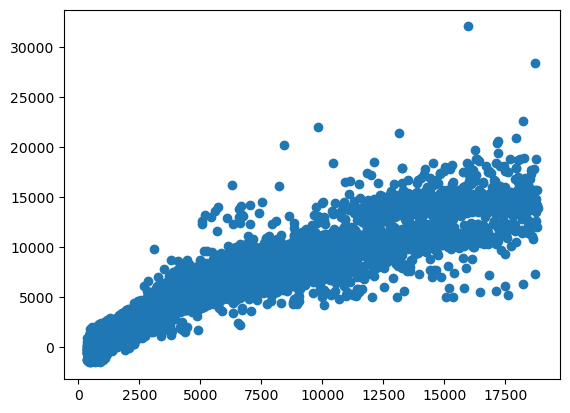

In [27]:
lineer=LinearRegression()
lineer.fit(X_train_scaled, y_train)

y_pred = lineer.predict(X_test_scaled)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2score=r2_score(y_test, y_pred)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

plt.scatter(y_test, y_pred)
plt.show()

### SVR icin deneyelim

In [28]:
from sklearn.svm import SVR

In [29]:
#svr=SVR()
#svr.fit(X_train_scaled, y_train)

#y_pred = svr.predict(X_test_scaled)

#mae=mean_absolute_error(y_test, y_pred)
#mse=mean_squared_error(y_test, y_pred)
#r2score=r2_score(y_test, y_pred)

#print("mean abs error: ", mae,"\n")
#print("mean sqr error: ", mse,"\n")
#print("r2 score: ",r2score, "\n")

#plt.scatter(y_test, y_pred)
#plt.show()

## Hyperparameter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV

[scikit-learn/SVR dökümantasyonuna gitmek icin tiklayiniz..](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)

### SVR icin SVC'de oldugu gibi gene ayni parametreler verebiliriz. Ayni mantik

In [31]:
parametreler={
    "C" : [0.01, 0.1, 1, 10, 100, 1000],
    "kernel" : ["linear", "rbf"], #poly vs de koyabilirz ama cok cok uzun surer hepsini denemesi
    "gamma" : ["scale", "auto"],
}

In [33]:
grid = GridSearchCV(estimator=SVR(), param_grid=parametreler, n_jobs=-1, verbose=3)

# verbose=3-->GridSearchCV'nin denediği her bir parametre kombinasyonu hakkında daha fazla detay görmeni sağlar

In [34]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             verbose=3)

In [35]:
print(grid.best_params_)

{'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}


mean abs error:  487.7269685378458 

mean sqr error:  949863.1710529792 

r2 score:  0.9415853758161926 



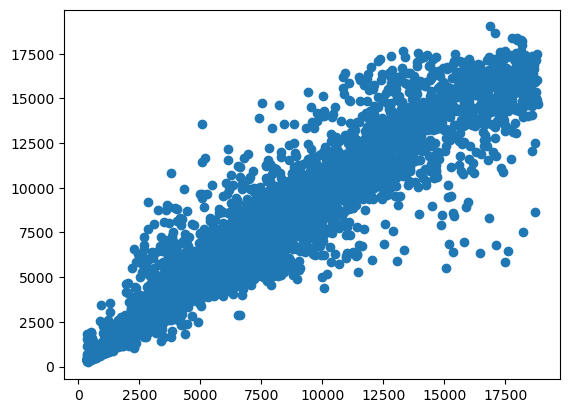

In [36]:
y_pred = grid.predict(X_test_scaled)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2score=r2_score(y_test, y_pred)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

plt.scatter(y_test, y_pred)
plt.show()